# Render

> Draw a layout with matplotlib, and the one-call `plot` function.

In [ ]:
#| default_exp render

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *
import tempfile
from matplotlib.colors import to_hex

Each set is drawn as the union of its cells, shrunk slightly so overlapping outlines don't sit on top of each other, with rounded corners. Zones are filled by multiplying light cyan, magenta and yellow tints, as if they were overlapping inks. Names are drawn as live text, so SVG and PDF output stays editable in Illustrator or Inkscape.

In [ ]:
#| export
from itertools import combinations
from pathlib import Path

import matplotlib
from matplotlib.colors import to_rgb
from matplotlib.figure import Figure
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea
from matplotlib.patches import PathPatch
from matplotlib.path import Path as MplPath
from shapely.geometry import MultiPolygon, Polygon, box
from shapely.ops import unary_union

from itemiset.layout import CELL_H_IN, PLACEHOLDER, Layout, cell_size, layout_sets, zone_rows

In [ ]:
#| export
# (light fill, dark outline and label) for the 1st, 2nd and 3rd set in input order
SET_COLOURS = [("#BDE8F8", "#1DA1D8"),   # cyan
               ("#F8C3DE", "#E0197D"),   # magenta
               ("#F7F0A6", "#A39300")]   # yellow
CATEGORY_PALETTE = ["#C8102E", "#2140A8", "#7B2A86", "#1A7F3C", "#C25400",
                    "#5E3C99", "#008080", "#8C510A"]

def multiply(colours) -> tuple:
    "Multiply colours like overlapping inks: cyan × magenta = lavender, and so on."
    r, g, b = 1.0, 1.0, 1.0
    for c in colours:
        cr, cg, cb = to_rgb(c)
        r, g, b = r * cr, g * cg, b * cb
    return (r, g, b)

In [ ]:
[to_hex(multiply([SET_COLOURS[i][0] for i in combo]))
 for k in (1, 2, 3) for combo in combinations(range(3), k)]

['#bde8f8', '#f8c3de', '#f7f0a6', '#b8b1d8', '#b7daa1', '#f0b891', '#b2a78d']

In [ ]:
#| export
def _geoms(g):
    if g.is_empty:
        return []
    if isinstance(g, Polygon):
        return [g]
    if isinstance(g, MultiPolygon):
        return list(g.geoms)
    return [p for p in getattr(g, "geoms", []) if isinstance(p, (Polygon, MultiPolygon))
            for p in _geoms(p)]

def _poly_to_path(geom):
    verts, codes = [], []
    for p in _geoms(geom):
        for ring in [p.exterior, *p.interiors]:
            xy = list(ring.coords)
            verts += xy
            codes += [MplPath.MOVETO] + [MplPath.LINETO] * (len(xy) - 2) + [MplPath.CLOSEPOLY]
    return MplPath(verts, codes) if verts else None

In [ ]:
#| export
def render(lay: Layout, out=None, categories=None, cat_colours=None, title=None,
           cell_w_in=None, cell_h_in=CELL_H_IN, fontsize=6.5, outline=True, dpi=300,
           corner=0.48, legend=True) -> Figure:
    "Draw `lay` as a matplotlib `Figure`, and save it to `out` (.png, .pdf or .svg) if given."
    categories = categories or {}
    items = [c.item for c in lay.cells if c.item]
    if cell_w_in is None:
        cell_w_in = cell_size(items, fontsize)[0]
    cw, ch = cell_w_in, cell_h_in
    set_order = lay.names

    # each set's outline, in inches: union of its cells, inset, with rounded corners
    colours = {s: SET_COLOURS[i % 3] for i, s in enumerate(set_order)}
    drawn = [s for s in set_order if any(s in c.zone for c in lay.cells)]
    insets = {s: ch * (0.05 + 0.07 * i) for i, s in enumerate(drawn)}
    set_poly = {}
    for s in drawn:
        boxes = [box(c.x * cw, c.y * ch, (c.x + 1) * cw, (c.y + 1) * ch)
                 for c in lay.cells if s in c.zone]
        p = unary_union(boxes).buffer(0)
        p = p.buffer(-insets[s], join_style="mitre")
        r = max(0.01, corner * (ch - 2 * insets[s]))
        p = p.buffer(r, join_style="round").buffer(-r, join_style="round")                  # round inner corners
        p = p.buffer(-r * 0.999, join_style="round").buffer(r * 0.999, join_style="round")  # round outer corners
        set_poly[s] = p

    minx = min(p.bounds[0] for p in set_poly.values())
    miny = min(p.bounds[1] for p in set_poly.values())
    maxx = max(p.bounds[2] for p in set_poly.values())
    maxy = max(p.bounds[3] for p in set_poly.values())
    roles = lay.roles
    lab_w, lab_h = 0.45, 0.45
    pad_l = lab_w if "A" in roles else 0.15
    pad_r = lab_w if "B" in roles else 0.15
    pad_b = lab_h if "C" in roles else 0.15
    pad_t = 0.1 + (0.3 if title else 0) + (0.25 if legend and categories else 0)
    need = 0.0                       # widen the canvas if the title or legend is wider than the diagram
    if title:
        need = max(need, 0.105 * len(title) + 0.2)
    if legend and categories:
        leg = "Legend: " + "   ".join(set(categories[i] for i in items if i in categories))
        need = max(need, 0.072 * len(leg) + 0.3)
    pad_r += max(0.0, need - ((maxx - minx) + pad_r))
    W_in = (maxx - minx) + pad_l + pad_r
    H_in = (maxy - miny) + pad_b + pad_t
    fig = Figure(figsize=(W_in, H_in))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_xlim(minx - pad_l, maxx + pad_r)
    ax.set_ylim(miny - pad_b, maxy + pad_t)
    ax.set_aspect("equal")
    ax.axis("off")

    # zones: the exact overlap regions of the rounded set shapes, in multiplied colours
    for k in range(1, len(drawn) + 1):
        for combo in combinations(drawn, k):
            g = set_poly[combo[0]]
            for s in combo[1:]:
                g = g.intersection(set_poly[s])
            for s in drawn:
                if s not in combo:
                    g = g.difference(set_poly[s])
            path = _poly_to_path(g)
            if path is not None:
                ax.add_patch(PathPatch(path, facecolor=multiply([colours[s][0] for s in combo]),
                                       edgecolor="none", zorder=1))
    if outline:
        for s in drawn:
            ax.add_patch(PathPatch(_poly_to_path(set_poly[s]), facecolor="none", edgecolor=colours[s][1],
                                   lw=0.8, alpha=0.7, zorder=2))

    # category colours: given ones first, then the palette
    present = set(categories[i] for i in items if i in categories)
    cats = [c for c in (cat_colours or {}) if c in present]
    cats += [c for c in dict.fromkeys(categories[i] for i in items if i in categories) if c not in cats]
    ccol = dict(cat_colours or {})
    pal = iter(c for c in CATEGORY_PALETTE if c not in ccol.values())
    for c in cats:
        ccol.setdefault(c, next(pal, "#444444"))

    for c in lay.cells:
        cx, cy = (c.x + 0.5) * cw, (c.y + 0.5) * ch
        if c.placeholder:
            ax.text(cx, cy, PLACEHOLDER, ha="center", va="center", fontsize=fontsize + 1,
                    color="#777777", zorder=3)
        elif c.item:
            cat = categories.get(c.item)
            ax.text(cx, cy, c.item, ha="center", va="center", fontsize=fontsize, zorder=3,
                    color=ccol[cat] if cat else "#222222",
                    fontweight="bold" if cat else "normal", family="DejaVu Sans")

    # set labels: left set on the left, right set on the right, bottom set underneath
    big = 15
    for role, s in roles.items():
        if s not in set_poly:
            continue
        b = set_poly[s].bounds
        col = colours[s][1]
        if role == "A":
            ax.text(minx - pad_l / 2, (b[1] + b[3]) / 2, s, rotation=90, ha="center",
                    va="center", fontsize=big, fontweight="bold", color=col)
        elif role == "B":
            ax.text(maxx + lab_w / 2, (b[1] + b[3]) / 2, s, rotation=270, ha="center",
                    va="center", fontsize=big, fontweight="bold", color=col)
        else:
            ax.text((b[0] + b[2]) / 2, miny - pad_b / 2, s, ha="center", va="center",
                    fontsize=big, fontweight="bold", color=col)
    if title:
        ax.text(minx, maxy + pad_t - 0.08, title, ha="left", va="top", fontsize=11, fontweight="bold")
    if legend and cats:
        parts = [TextArea("Legend: ", textprops=dict(fontsize=7.5, fontweight="bold"))]
        for c in cats:
            parts.append(TextArea(c + "   ", textprops=dict(fontsize=7.5, color=ccol[c], fontweight="bold")))
        pack = HPacker(children=parts, pad=0, sep=0)
        y = (maxy + 0.12 - miny + pad_b) / H_in
        ax.add_artist(AnchoredOffsetbox(loc="lower left", child=pack, frameon=False,
                                        bbox_to_anchor=((pad_l * 0.9) / W_in, y),
                                        bbox_transform=fig.transFigure, borderpad=0))
    lay.fig = fig
    if out is not None:
        with matplotlib.rc_context({"svg.fonttype": "none", "pdf.fonttype": 42}):
            fig.savefig(out, dpi=dpi)
    return fig

## `plot`: sets in, figure out

In [ ]:
#| export
def plot(sets: dict, out=None, categories=None, category_colours=None, show_empty=False, bottom=None,
         title=None, target_aspect=2.2, fontsize=6.5, zones_out=None, verbose=False, **render_kw) -> Layout:
    "Lay out and draw 1–3 sets given as `{name: [items]}`. Returns the `Layout`; its figure is `.fig`."
    lay = layout_sets(sets, show_empty=show_empty, bottom=bottom, target_aspect=target_aspect, fontsize=fontsize)
    render(lay, out, categories=categories, cat_colours=category_colours, title=title,
           fontsize=fontsize, **render_kw)
    if zones_out:
        import pandas as pd
        pd.DataFrame(zone_rows(lay, categories)).to_csv(zones_out, index=False)
    if verbose:
        if out: print(f"Wrote {out}")
        print("Roles:", ", ".join(f"{k}={v}" for k, v in sorted(lay.roles.items())),
              "| group widths (L, M, R):", tuple(lay.widths))
        for z, n in sorted(lay.counts.items(), key=lambda t: (len(t[0]), [lay.names.index(s) for s in t[0]])):
            print(f"  {' ∩ '.join(s for s in lay.names if s in z):45s} {n:5d}")
        for n in lay.notes:
            print("Note:", n)
    return lay

A layout shows its figure when it's the last thing in a notebook cell:

Roles: A=Right, B=Bottom, C=Left | group widths (L, M, R): (1, 1, 1)
  Left                                              3
  Right                                             2
  Bottom                                            3
  Left ∩ Right                                      2
  Right ∩ Bottom                                    1
  Left ∩ Bottom                                     1
  Left ∩ Right ∩ Bottom                             2


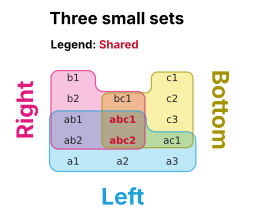

In [ ]:
demo = {"Left":   ["a1", "a2", "a3", "ab1", "ab2", "ac1", "abc1", "abc2"],
        "Right":  ["b1", "b2", "ab1", "ab2", "bc1", "abc1", "abc2"],
        "Bottom": ["c1", "c2", "c3", "ac1", "bc1", "abc1", "abc2"]}
lay = plot(demo, categories={"abc1": "Shared", "abc2": "Shared"}, title="Three small sets", verbose=True)
lay

Output format follows the file extension. In SVG the names stay as text:

In [ ]:
tmp = Path(tempfile.mkdtemp())
for ext in ("png", "pdf", "svg"):
    plot(demo, out=tmp/f"demo.{ext}")
    assert (tmp/f"demo.{ext}").stat().st_size > 1000
svg = (tmp/"demo.svg").read_text()
assert ">abc1</text>" in svg  # live text, not outlines

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()